<a href="https://colab.research.google.com/github/LeylaY1996/sentiment-analysis-aws-reviews/blob/main/04082026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

leylayilmaz_amazon_path = kagglehub.dataset_download('leylayilmaz/amazon')

print('Data source import complete.')


<a href="https://colab.research.google.com/github/LeylaY1996/sentiment-analysis-aws-reviews/blob/main/23022026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

leylayilmaz_amazon_path = kagglehub.dataset_download('leylayilmaz/amazon')

print('Data source import complete.')


Data source import complete.


[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


######################################
Orijinal veri seti boyutu: (568454, 10)
######################################

Prepared Data Sınıf Dağılımı:
Sentiment
1    443777
0     82037
Name: count, dtype: int64

Yüzdesel Dağılım:
Sentiment
1    84.398095
0    15.601905
Name: proportion, dtype: float64


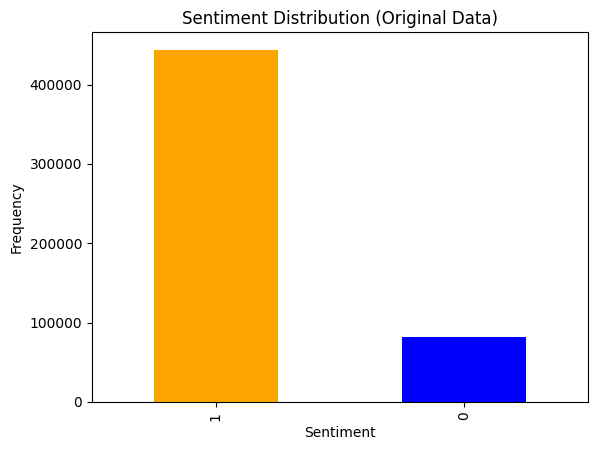


• Ortalama kelime sayısı: 40.87
• Standart sapma (kelime): 42.11

Aykırı değerler çıkarıldıktan sonra veri seti boyutu: (516292, 6)
Kullanılan veri seti boyutu: (103258, 6)
                                           cleaned_review  Sentiment  \
220021  like curry product easy use tastes great recom...          1   
284398  friend young twins purees well recieved nice p...          1   
485130  goodness sakes got snack work trips theyre har...          0   
143256  im learning starting train dogs went amazon lo...          1   
293634  received product match invoice without explana...          1   

         ProductId          UserId  review_length  char_length  
220021  B003NAWM0A   AR3LDOEXJIMAH              9           57  
284398  B0051COPH6  A20L63B48RPSOH             19          121  
485130  B00018CWZ2  A11YOTONCPRQ9S             28          170  
143256  B0007A0AQM  A2ASPZEBHAWVY8             29          176  
293634  B004E580PE   AAGXUCFRT40DZ             37          295  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import string
from scipy import stats

# Stopwords yükle
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
punctuation = string.punctuation

def clean_text(text):
    """Metni temizler: küçük harfe çevirir, noktalama işaretlerini kaldırır ve durak kelimeleri filtreler."""
    text = str(text).lower()
    text = ''.join([char for char in text if char not in punctuation])
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

def prepare_data(csv_file):
    """Veri setini hazırlar: yükler, temizler ve etiketler."""
    df = pd.read_csv(csv_file)

    print("######################################")
    print("Orijinal veri seti boyutu:", df.shape)
    print("######################################")

    # Gerekli sütunları seç
    df = df[['Text', 'Score', 'ProductId', 'UserId']]

    # Score 3 olanları çıkar
    df = df[df['Score'] != 3]

    # Sentiment etiketini oluştur
    df['Sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

    # Yorumları temizle
    df['cleaned_review'] = df['Text'].apply(clean_text)

    return df[['cleaned_review', 'Sentiment', 'ProductId', 'UserId']]

# Veriyi yükle
csv_file_path = '/kaggle/input/datasets/leylayilmaz/amazon/Reviews 3.csv'
prepared_data = prepare_data(csv_file_path)

# 🔴 Gerçek sınıf dağılımını göster
print("\nPrepared Data Sınıf Dağılımı:")
print(prepared_data['Sentiment'].value_counts())

print("\nYüzdesel Dağılım:")
print(prepared_data['Sentiment'].value_counts(normalize=True) * 100)

# Histogram (GERÇEK VERİ)
prepared_data['Sentiment'].value_counts().plot(
    kind='bar',
    color=['orange', 'blue']
)
plt.title('Sentiment Distribution (Original Data)')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.show()

# Yorum uzunluklarını hesapla
prepared_data['review_length'] = prepared_data['cleaned_review'].apply(lambda x: len(x.split()))
prepared_data['char_length'] = prepared_data['cleaned_review'].apply(len)

# İstatistikler
mean_word_length = prepared_data['review_length'].mean()
std_word_length = prepared_data['review_length'].std()

print(f"\n• Ortalama kelime sayısı: {mean_word_length:.2f}")
print(f"• Standart sapma (kelime): {std_word_length:.2f}")

# Aykırı değer temizliği
z_scores = np.abs(stats.zscore(prepared_data['review_length']))
filtered_data = prepared_data[(z_scores < 3)]

print("\nAykırı değerler çıkarıldıktan sonra veri seti boyutu:", filtered_data.shape)

# Performans için örnekleme (%20)
filtered_data = filtered_data.sample(frac=0.2, random_state=42)
print("Kullanılan veri seti boyutu:", filtered_data.shape)

print(filtered_data.head())

In [ ]:
def plot_confusion_matrix(cm, title="Karmaşıklık Matrisi"):
    """Confusion matrix'i Türkçe etiketlerle görselleştirir."""

    fig, ax = plt.subplots(figsize=(6,6))
    ax.matshow(cm, cmap='Blues', alpha=0.6)

    # Hücre değerlerini yazdır
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center', color='red')

    # Eksen etiketleri
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["Negatif (0)", "Pozitif (1)"])
    ax.set_yticklabels(["Negatif (0)", "Pozitif (1)"])

    plt.xlabel("Tahmin Edilen Sınıf")
    plt.ylabel("Gerçek Sınıf")
    plt.title(title)
    plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def vectorize_text(train_text, test_text, max_features=10000, ngram_range=(1, 2)):
    """
    Metinleri TF-IDF ile vektörize eder.
    """
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    X_train_tfidf = vectorizer.fit_transform(train_text)
    X_test_tfidf = vectorizer.transform(test_text)

    return X_train_tfidf, X_test_tfidf, vectorizer

In [ ]:
from sklearn.model_selection import train_test_split

# Gerçek veri üzerinden train/test ayır
train_text, test_text, y_train, y_test = train_test_split(
    filtered_data['cleaned_review'],
    filtered_data['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=filtered_data['Sentiment']   # 🔴 ÇOK ÖNEMLİ
)

print("Train dağılımı:")
print(y_train.value_counts())
print("\nTest dağılımı:")
print(y_test.value_counts())

# TF-IDF ile vektörleştir
X_train_tfidf, X_test_tfidf, vectorizer = vectorize_text(train_text, test_text)

# Kontrol
print("\nTF-IDF eğitim matris boyutu:", X_train_tfidf.shape)
print("TF-IDF test matris boyutu:", X_test_tfidf.shape)

Train dağılımı:
Sentiment
1    69668
0    12938
Name: count, dtype: int64

Test dağılımı:
Sentiment
1    17417
0     3235
Name: count, dtype: int64

TF-IDF eğitim matris boyutu: (82606, 10000)
TF-IDF test matris boyutu: (20652, 10000)


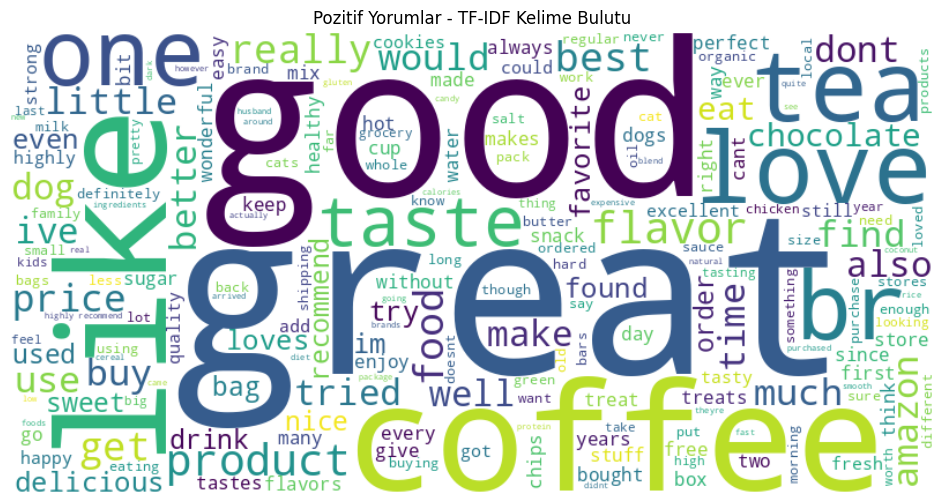

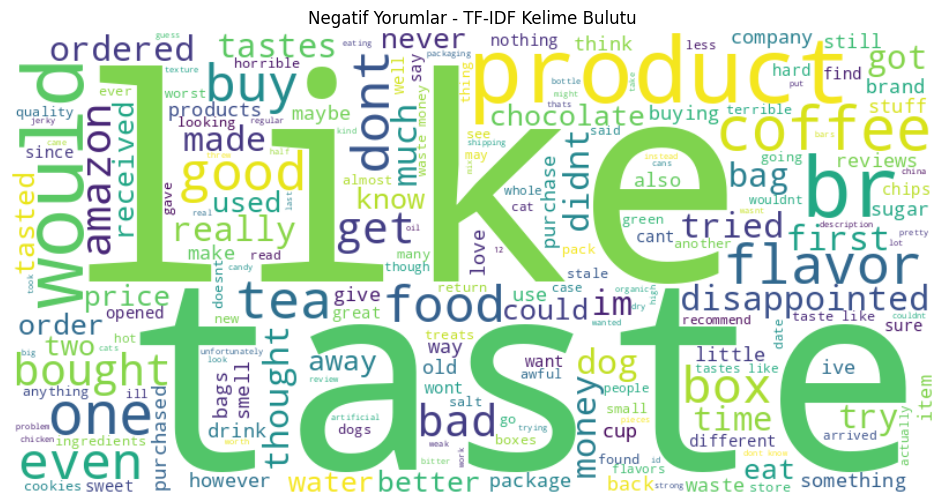

In [ ]:
from wordcloud import WordCloud
def plot_class_wordcloud(vectorizer, X_tfidf, y_labels, target_class, title):
    feature_names = vectorizer.get_feature_names_out()

    # Sadece ilgili sınıfı seç
    class_indices = np.where(y_labels == target_class)[0]
    X_class = X_tfidf[class_indices]

    tfidf_means = np.asarray(X_class.mean(axis=0)).flatten()
    word_weights = {word: tfidf_means[i] for i, word in enumerate(feature_names)}

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_weights)

    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

# Pozitif kelime bulutu
plot_class_wordcloud(vectorizer, X_train_tfidf, y_train.values, 1, "Pozitif Yorumlar - TF-IDF Kelime Bulutu")

# Negatif kelime bulutu
plot_class_wordcloud(vectorizer, X_train_tfidf, y_train.values, 0, "Negatif Yorumlar - TF-IDF Kelime Bulutu")

In [ ]:
from sklearn.model_selection import train_test_split

def split_data(df, feature_column, target_column, test_size=0.2, random_state=42):
    """
    Veri çerçevesini eğitim ve test setine böler.

    Args:
    - df: Veri çerçevesi (pandas DataFrame).
    - feature_column: Özellik sütunu adı (ör. metin verisi).
    - target_column: Hedef sütunu adı (etiketler).
    - test_size: Test setinin boyutu (varsayılan: 0.2).
    - random_state: Rastgele durum kontrolü için tohum (varsayılan: 42).

    Returns:
    - X_train: Eğitim seti özellikleri.
    - X_test: Test seti özellikleri.
    - y_train: Eğitim seti etiketleri.
    - y_test: Test seti etiketleri.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        df[feature_column],
        df[target_column],
        test_size=test_size,
        random_state=random_state,
        stratify=df[target_column]  # Sınıf dengesini korumak için stratify
    )
    return X_train, X_test, y_train, y_test

In [ ]:
print("SMOTE Öncesi Sınıf Dağılımı:")
print(y_train.value_counts())

print("\nYüzdesel Dağılım:")
print(y_train.value_counts(normalize=True) * 100)

SMOTE Öncesi Sınıf Dağılımı:
Sentiment
1    69668
0    12938
Name: count, dtype: int64

Yüzdesel Dağılım:
Sentiment
1    84.337699
0    15.662301
Name: proportion, dtype: float64


In [ ]:
from imblearn.over_sampling import SMOTE

def apply_smote(X, y, random_state=42):
    """
    SMOTE ile azınlık sınıfını artırır.
    """
    smote = SMOTE(random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    return X_resampled, y_resampled

In [ ]:
# SMOTE uygula
X_train_smote, y_train_smote = apply_smote(X_train_tfidf, y_train)

print("SMOTE Sonrası Sınıf Dağılımı:")
print(pd.Series(y_train_smote).value_counts())

print("\nYüzdesel Dağılım:")
print(pd.Series(y_train_smote).value_counts(normalize=True) * 100)

SMOTE Sonrası Sınıf Dağılımı:
Sentiment
0    69668
1    69668
Name: count, dtype: int64

Yüzdesel Dağılım:
Sentiment
0    50.0
1    50.0
Name: proportion, dtype: float64


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Modeli eğitir ve değerlendirme metriklerini döner.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, report, cm

In [ ]:
def run_model(df, model, use_smote=False, model_name="Model"):

    X_train, X_test, y_train, y_test = split_data(
        df, 'cleaned_review', 'Sentiment'
    )

    X_train_tfidf, X_test_tfidf, _ = vectorize_text(X_train, X_test)

    if use_smote:
        X_train_tfidf, y_train = apply_smote(X_train_tfidf, y_train)

    accuracy, report, cm = train_and_evaluate_model(
        model,
        X_train_tfidf,
        y_train,
        X_test_tfidf,
        y_test
    )

    print(f"\n{model_name} - SMOTE {'VAR' if use_smote else 'YOK'}")
    print("Accuracy:", accuracy)
    print(report)

    plot_confusion_matrix(
        cm,
        f"{model_name} - SMOTE {'VAR' if use_smote else 'YOK'}"
    )

    return accuracy, report, cm


SVM - SMOTE YOK
Accuracy: 0.9341468138679062
              precision    recall  f1-score   support

           0       0.83      0.73      0.78      3235
           1       0.95      0.97      0.96     17417

    accuracy                           0.93     20652
   macro avg       0.89      0.85      0.87     20652
weighted avg       0.93      0.93      0.93     20652



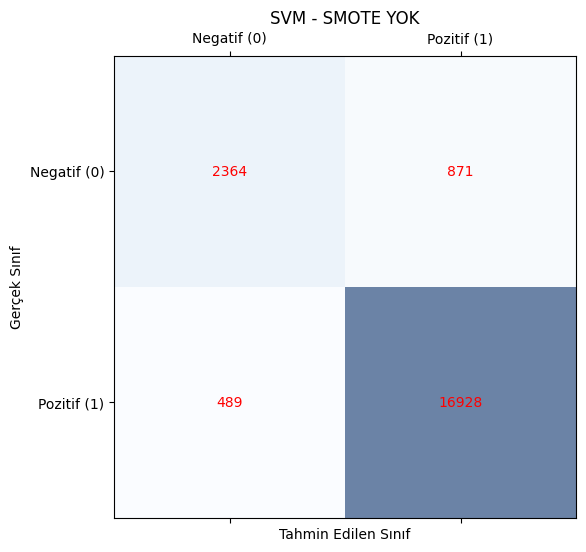


SVM - SMOTE VAR
Accuracy: 0.920879333720705
              precision    recall  f1-score   support

           0       0.71      0.84      0.77      3235
           1       0.97      0.94      0.95     17417

    accuracy                           0.92     20652
   macro avg       0.84      0.89      0.86     20652
weighted avg       0.93      0.92      0.92     20652



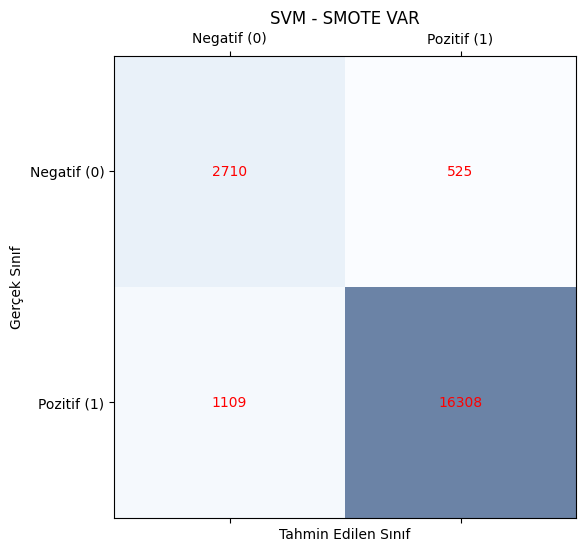

(0.920879333720705,
 '              precision    recall  f1-score   support\n\n           0       0.71      0.84      0.77      3235\n           1       0.97      0.94      0.95     17417\n\n    accuracy                           0.92     20652\n   macro avg       0.84      0.89      0.86     20652\nweighted avg       0.93      0.92      0.92     20652\n',
 array([[ 2710,   525],
        [ 1109, 16308]]))

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

run_model(filtered_data, svm_model, use_smote=False, model_name="SVM")
run_model(filtered_data, svm_model, use_smote=True, model_name="SVM")


Naive Bayes - SMOTE YOK
Accuracy: 0.8955064884756925
              precision    recall  f1-score   support

           0       0.91      0.37      0.53      3235
           1       0.89      0.99      0.94     17417

    accuracy                           0.90     20652
   macro avg       0.90      0.68      0.73     20652
weighted avg       0.90      0.90      0.88     20652



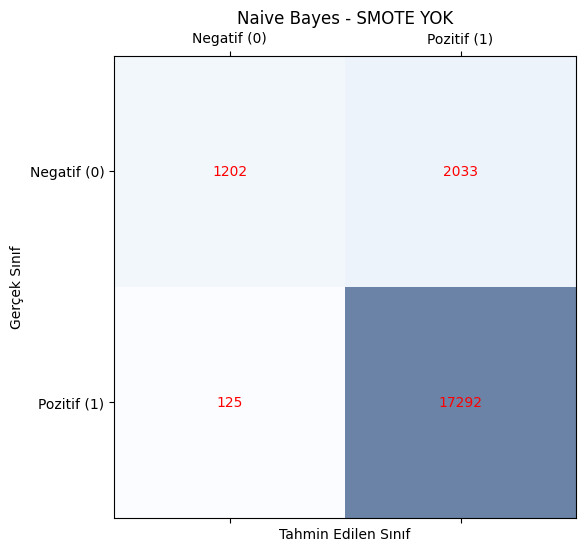

(0.8955064884756925,
 '              precision    recall  f1-score   support\n\n           0       0.91      0.37      0.53      3235\n           1       0.89      0.99      0.94     17417\n\n    accuracy                           0.90     20652\n   macro avg       0.90      0.68      0.73     20652\nweighted avg       0.90      0.90      0.88     20652\n',
 array([[ 1202,  2033],
        [  125, 17292]]))

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

run_model(
    filtered_data,
    nb_model,
    use_smote=False,
    model_name="Naive Bayes"
)


Naive Bayes - SMOTE VAR
Accuracy: 0.8906643424365679
              precision    recall  f1-score   support

           0       0.61      0.87      0.71      3235
           1       0.97      0.90      0.93     17417

    accuracy                           0.89     20652
   macro avg       0.79      0.88      0.82     20652
weighted avg       0.92      0.89      0.90     20652



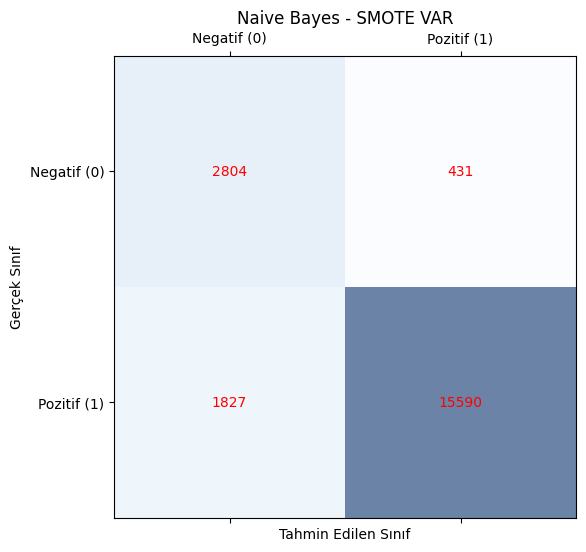

(0.8906643424365679,
 '              precision    recall  f1-score   support\n\n           0       0.61      0.87      0.71      3235\n           1       0.97      0.90      0.93     17417\n\n    accuracy                           0.89     20652\n   macro avg       0.79      0.88      0.82     20652\nweighted avg       0.92      0.89      0.90     20652\n',
 array([[ 2804,   431],
        [ 1827, 15590]]))

In [ ]:
nb_model = MultinomialNB()

run_model(
    filtered_data,
    nb_model,
    use_smote=True,
    model_name="Naive Bayes"
)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def preprocess_text_with_tokenizer(train_text, test_text, max_length=100):
    """
    Metinleri tokenize eder ve belirli bir uzunlukta padding uygular.
    """
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(train_text)

    # Sayısal verilere dönüştürme
    train_seq = tokenizer.texts_to_sequences(train_text)
    test_seq = tokenizer.texts_to_sequences(test_text)

    # Padding işlemi
    train_padded = pad_sequences(train_seq, maxlen=max_length, padding='post')
    test_padded = pad_sequences(test_seq, maxlen=max_length, padding='post')

    return train_padded, test_padded, tokenizer

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

def build_rnn_model(input_dim, max_length, embedding_dim=100):
    """
    RNN (Bidirectional LSTM) modeli oluşturur.
    """
    model = Sequential()
    model.add(Embedding(input_dim=input_dim, output_dim=embedding_dim, input_length=max_length))
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(Dropout(0.3))
    model.add(Bidirectional(LSTM(32)))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-08-04 09:45:30.818498: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 270s 203ms/step - accuracy: 0.8443 - loss: 0.3537 - val_accuracy: 0.8565 - val_loss: 0.3558
Epoch 2/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 262s 203ms/step - accuracy: 0.9298 - loss: 0.1860 - val_accuracy: 0.9241 - val_loss: 0.2010
Epoch 3/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 263s 204ms/step - accuracy: 0.9556 - loss: 0.1196 - val_accuracy: 0.9022 - val_loss: 0.3084
Epoch 4/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 267s 207ms/step - accuracy: 0.9695 - loss: 0.0844 - val_accuracy: 0.9163 - val_loss: 0.2631
Epoch 5/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 265s 205ms/step - accuracy: 0.9781 - loss: 0.0625 - val_accuracy: 0.9092 - val_loss: 0.3281
646/646 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step
RNN Accuracy: 0.9092097617664149
              precision    recall  f1-score   support

           0       0.67      0.83      0.74      3235
           1       0.97      0.92      0.94     17417

    accuracy                           0.91     20652
   macro avg       0.82      0.88      0.

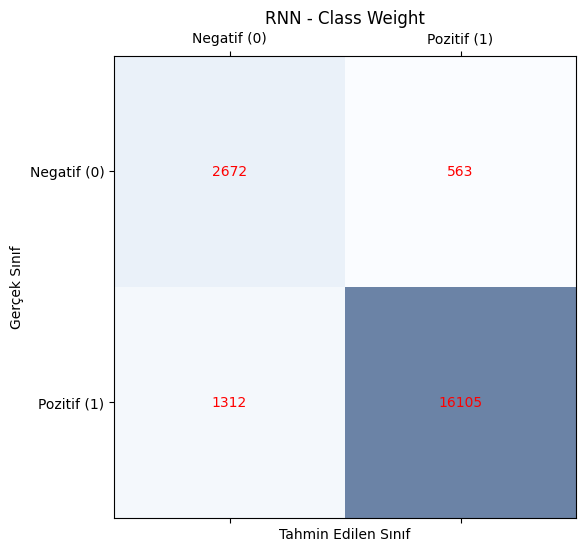

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

def rnn_with_class_weight(df):
    """RNN (Bidirectional LSTM) ve class_weight kullanarak duygu analizi yapar."""

    # Eğitim ve test setine ayırma
    X_train, X_test, y_train, y_test = split_data(
        df,
        'cleaned_review',
        'Sentiment'
    )

    # Tokenize + Padding
    max_length = 100
    X_train_padded, X_test_padded, tokenizer = preprocess_text_with_tokenizer(
        X_train,
        X_test,
        max_length
    )

       # 🔴 BURAYI EKLE
    y_train = np.array(y_train)
    y_test = np.array(y_test)
    # Class weight hesapla
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = dict(enumerate(class_weights))

    # Model oluştur
    input_dim = len(tokenizer.word_index) + 1
    model = build_rnn_model(input_dim, max_length)

    # Modeli eğit
    model.fit(
        X_train_padded,
        y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_test_padded, y_test),
        class_weight=class_weights,
        verbose=1
    )

    # Tahmin
    y_pred = (model.predict(X_test_padded) > 0.5).astype("int32").flatten()

    # Değerlendirme
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, report, cm

accuracy, report, cm = rnn_with_class_weight(filtered_data)

print("RNN Accuracy:", accuracy)
print(report)
print(cm)

plot_confusion_matrix(cm, "RNN - Class Weight")

Lexicon Accuracy: 0.5574483333010517
              precision    recall  f1-score   support

           0       0.23      0.75      0.35     16173
           1       0.92      0.52      0.67     87085

    accuracy                           0.56    103258
   macro avg       0.57      0.64      0.51    103258
weighted avg       0.81      0.56      0.62    103258

[[12166  4007]
 [41690 45395]]


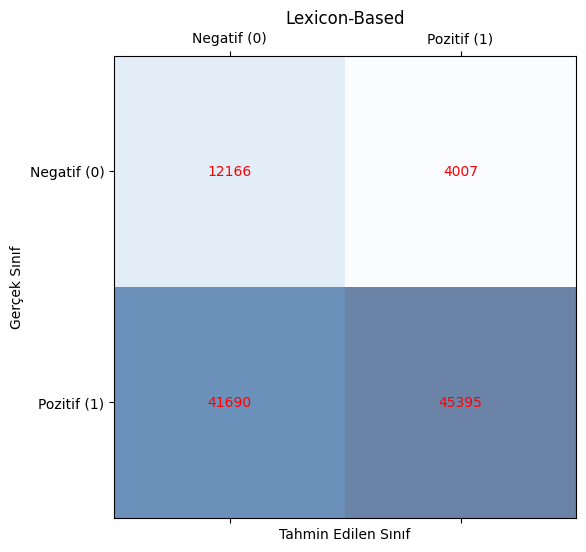

In [ ]:
def lexicon_based_sentiment_analysis(df):

    positive_words = ['good', 'great', 'excellent', 'awesome', 'nice']
    negative_words = ['bad', 'terrible', 'poor', 'worst', 'awful']

    def get_sentiment(text):
        words = text.split()
        score = 0
        for word in words:
            if word in positive_words:
                score += 1
            elif word in negative_words:
                score -= 1
        return 1 if score > 0 else 0

    y_true = df['Sentiment']
    y_pred = df['cleaned_review'].apply(get_sentiment)

    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    return accuracy, report, cm
accuracy, report, cm = lexicon_based_sentiment_analysis(filtered_data)

print("Lexicon Accuracy:", accuracy)
print(report)
print(cm)

plot_confusion_matrix(cm, "Lexicon-Based")

In [ ]:
def extract_aspect_features(df):

    aspects = {
        'hız': ['fast', 'quick', 'speed', 'late', 'delayed'],
        'kalite': ['good', 'great', 'excellent', 'poor', 'bad', 'terrible', 'quality']
    }

    def extract(text):
        words = text.split()
        features = []
        for aspect, keywords in aspects.items():
            count = sum(word in keywords for word in words)
            features.append(count)
        return features

    X = np.array(df['cleaned_review'].apply(extract).tolist())
    y = df['Sentiment'].values

    return X, y

Aspect - Class Weight
0.5511814836335464
              precision    recall  f1-score   support

           0       0.19      0.60      0.29      3235
           1       0.88      0.54      0.67     17417

    accuracy                           0.55     20652
   macro avg       0.54      0.57      0.48     20652
weighted avg       0.77      0.55      0.61     20652



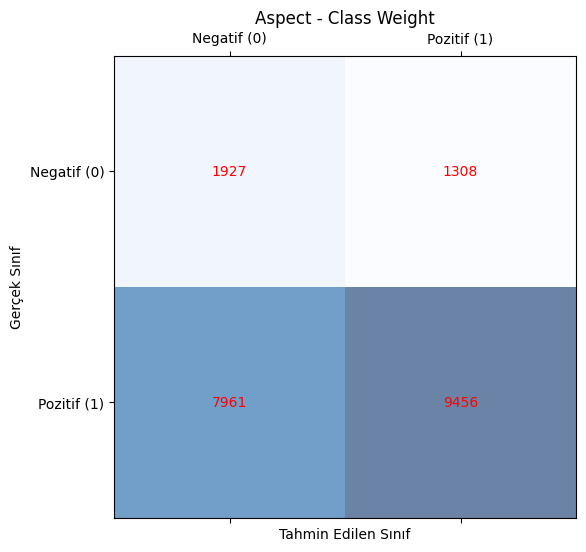

In [ ]:
# ============================================================================
# Hedef Tabanlı (Aspect-Based) Yöntem - Class Weight
# ============================================================================
# Bu hücreyi notebook'ta cell 26-27'den (Aspect - SMOTE YOK / SMOTE VAR)
# sonraya ekle. extract_aspect_features fonksiyonunu (cell 24) ve
# filtered_data değişkenini (cell 6) kullanır, TensorFlow gerektirmez.
#
# Amaç: cell 25'teki run_model_with_features fonksiyonu SMOTE uyguluyordu;
# burada onun yerine RandomForestClassifier'ın class_weight='balanced'
# parametresini kullanan bir varyant tanımlanıyor, böylece Hedef Tabanlı
# yöntem de SVM/Naive Bayes/Lojistik Regresyon gibi hem SMOTE hem
# Class Weight ile karşılaştırılabiliyor.
# ============================================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


def run_model_with_features_classweight(X, y, model):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return accuracy, report, cm


X, y = extract_aspect_features(filtered_data)

model_cw = RandomForestClassifier(random_state=42, class_weight='balanced')
accuracy_cw, report_cw, cm_cw = run_model_with_features_classweight(X, y, model_cw)

print("Aspect - Class Weight")
print(accuracy_cw)
print(report_cw)
plot_confusion_matrix(cm_cw, "Aspect - Class Weight")

In [ ]:
def run_model_with_features(X, y, model, use_smote=True):

    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    if use_smote:
        X_train, y_train = apply_smote(X_train, y_train)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, report, cm

Aspect - SMOTE YOK
0.8433565756343211
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3235
           1       0.84      1.00      0.92     17417

    accuracy                           0.84     20652
   macro avg       0.42      0.50      0.46     20652
weighted avg       0.71      0.84      0.77     20652



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


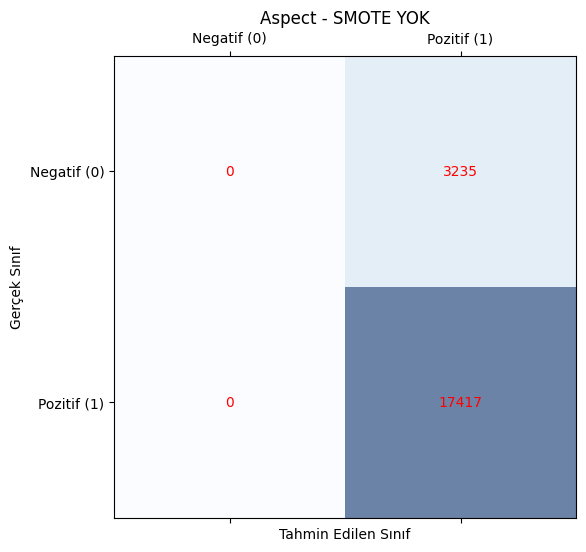

In [ ]:
from sklearn.ensemble import RandomForestClassifier
X, y = extract_aspect_features(filtered_data)

accuracy_ns, report_ns, cm_ns = run_model_with_features(
    X,
    y,
    RandomForestClassifier(random_state=42),
    use_smote=False
)

print("Aspect - SMOTE YOK")
print(accuracy_ns)
print(report_ns)
plot_confusion_matrix(cm_ns, "Aspect - SMOTE YOK")

Aspect - SMOTE VAR
0.5512299050939377
              precision    recall  f1-score   support

           0       0.19      0.60      0.29      3235
           1       0.88      0.54      0.67     17417

    accuracy                           0.55     20652
   macro avg       0.54      0.57      0.48     20652
weighted avg       0.77      0.55      0.61     20652



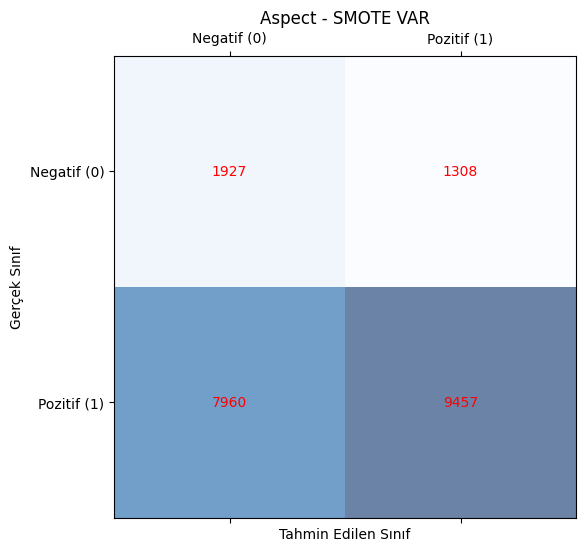

In [ ]:
accuracy_s, report_s, cm_s = run_model_with_features(
    X,
    y,
    RandomForestClassifier(random_state=42),
    use_smote=True
)

print("Aspect - SMOTE VAR")
print(accuracy_s)
print(report_s)
plot_confusion_matrix(cm_s, "Aspect - SMOTE VAR")

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dropout

def build_cnn_model(input_dim, max_length, embedding_dim=100):

    model = Sequential()
    model.add(Embedding(input_dim=input_dim, output_dim=embedding_dim))
    model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

Epoch 1/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 89s 67ms/step - accuracy: 0.8482 - loss: 0.3341 - val_accuracy: 0.9175 - val_loss: 0.2129
Epoch 2/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 89s 69ms/step - accuracy: 0.9430 - loss: 0.1506 - val_accuracy: 0.9111 - val_loss: 0.2359
Epoch 3/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 86s 66ms/step - accuracy: 0.9778 - loss: 0.0587 - val_accuracy: 0.9232 - val_loss: 0.2499
Epoch 4/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 85s 66ms/step - accuracy: 0.9902 - loss: 0.0270 - val_accuracy: 0.9209 - val_loss: 0.3005
Epoch 5/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 85s 66ms/step - accuracy: 0.9937 - loss: 0.0167 - val_accuracy: 0.9178 - val_loss: 0.3878
646/646 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
CNN Accuracy: 0.9177803602556653
              precision    recall  f1-score   support

           0       0.71      0.81      0.76      3235
           1       0.96      0.94      0.95     17417

    accuracy                           0.92     20652
   macro avg       0.84      0.87      0.85     20652

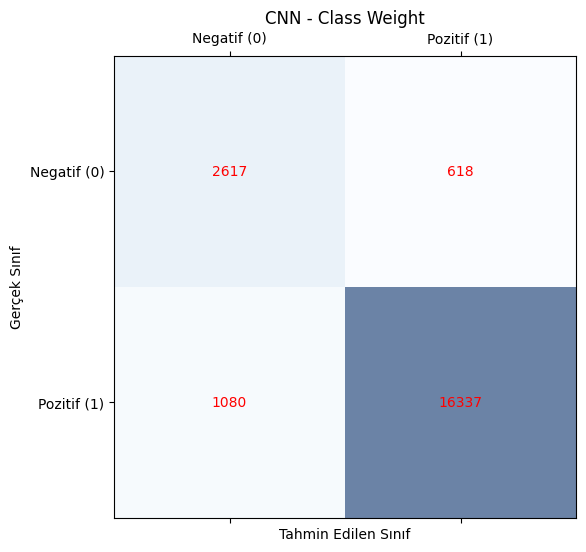

In [ ]:
def cnn_with_class_weight(df):

    X_train, X_test, y_train, y_test = split_data(
        df,
        'cleaned_review',
        'Sentiment'
    )

    max_length = 100

    X_train_pad, X_test_pad, tokenizer = preprocess_text_with_tokenizer(
        X_train,
        X_test,
        max_length
    )

    y_train = np.array(y_train)
    y_test = np.array(y_test)

    from sklearn.utils.class_weight import compute_class_weight

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = dict(enumerate(class_weights))

    input_dim = len(tokenizer.word_index) + 1
    model = build_cnn_model(input_dim, max_length)

    model.fit(
        X_train_pad,
        y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_test_pad, y_test),
        class_weight=class_weights,
        verbose=1
    )

    y_pred = (model.predict(X_test_pad) > 0.5).astype(int).flatten()

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, report, cm

accuracy, report, cm = cnn_with_class_weight(filtered_data)

print("CNN Accuracy:", accuracy)
print(report)
print(cm)

plot_confusion_matrix(cm, "CNN - Class Weight")

In [ ]:
def run_tfidf_model(df, model, use_smote=True):

    X_train, X_test, y_train, y_test = split_data(
        df,
        'cleaned_review',
        'Sentiment'
    )

    X_train_tfidf, X_test_tfidf, _ = vectorize_text(X_train, X_test)

    if use_smote:
        X_train_tfidf, y_train = apply_smote(X_train_tfidf, y_train)

    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, report, cm

Logistic Regression - SMOTE YOK
0.9264478016656983
              precision    recall  f1-score   support

           0       0.87      0.62      0.73      3235
           1       0.93      0.98      0.96     17417

    accuracy                           0.93     20652
   macro avg       0.90      0.80      0.84     20652
weighted avg       0.92      0.93      0.92     20652



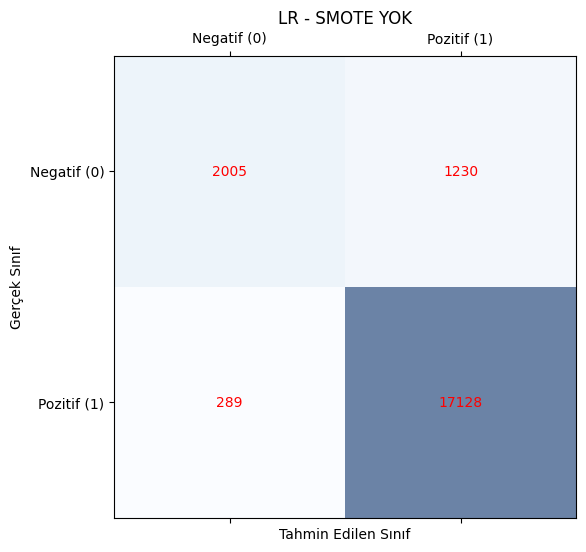

In [ ]:
from sklearn.linear_model import LogisticRegression
accuracy_ns, report_ns, cm_ns = run_tfidf_model(
    filtered_data,
    LogisticRegression(max_iter=1000, random_state=42),
    use_smote=False
)

print("Logistic Regression - SMOTE YOK")
print(accuracy_ns)
print(report_ns)
plot_confusion_matrix(cm_ns, "LR - SMOTE YOK")

Logistic Regression - SMOTE VAR
0.9138098005035832
              precision    recall  f1-score   support

           0       0.68      0.87      0.76      3235
           1       0.97      0.92      0.95     17417

    accuracy                           0.91     20652
   macro avg       0.82      0.89      0.85     20652
weighted avg       0.93      0.91      0.92     20652



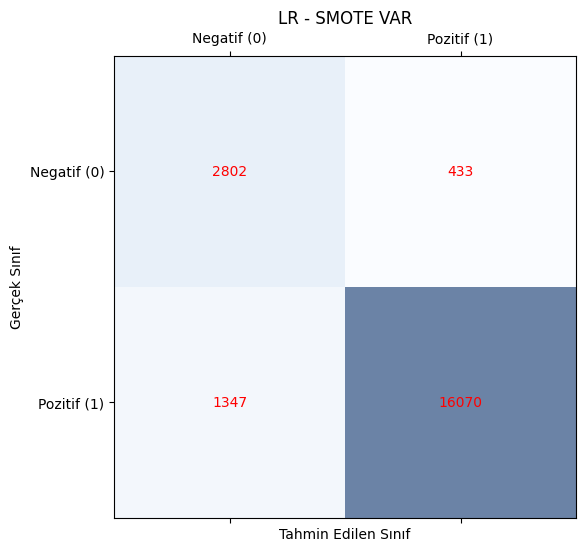

In [ ]:
accuracy_s, report_s, cm_s = run_tfidf_model(
    filtered_data,
    LogisticRegression(max_iter=1000, random_state=42),
    use_smote=True
)

print("Logistic Regression - SMOTE VAR")
print(accuracy_s)
print(report_s)
plot_confusion_matrix(cm_s, "LR - SMOTE VAR")

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd

def run_tfidf_model(df, model, model_name, use_smote=False):

    # Train / Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        df['cleaned_review'],
        df['Sentiment'],
        test_size=0.2,
        random_state=42,
        stratify=df['Sentiment']
    )

    # TF-IDF
    X_train_tfidf, X_test_tfidf, _ = vectorize_text(X_train, X_test)

    # SMOTE sadece train'e
    if use_smote:
        X_train_tfidf, y_train = apply_smote(X_train_tfidf, y_train)

    # Model eğit
    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    report = classification_report(y_test, y_pred, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)

    return {
        "Model": model_name,
        "SMOTE": "VAR" if use_smote else "YOK",
        "Accuracy": accuracy,
        "Precision_0": report["0"]["precision"],
        "Recall_0": report["0"]["recall"],
        "F1_0": report["0"]["f1-score"],
        "Macro_F1": report["macro avg"]["f1-score"],
        "Weighted_F1": report["weighted avg"]["f1-score"]
    }

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

results = []

models = [
    ("SVM", LinearSVC()),
    ("Naive Bayes", MultinomialNB()),
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42))
]

for name, model in models:
    # SMOTE YOK
    results.append(run_tfidf_model(filtered_data, model, name, use_smote=False))

    # SMOTE VAR
    results.append(run_tfidf_model(filtered_data, model, name, use_smote=True))

In [ ]:
# RNN ekle
results.append({
    "Model": "RNN (BiLSTM)",
    "SMOTE": "ClassWeight",
    "Accuracy": 0.9047,
    "Precision_0": 0.65,
    "Recall_0": 0.84,
    "F1_0": 0.73,
    "Macro_F1": 0.84,
    "Weighted_F1": 0.91
})

results.append({
    "Model": "CNN",
    "SMOTE": "SMOTE",
    "Accuracy": 0.9243,
    "Precision_0": 0.75,
    "Recall_0": 0.78,
    "F1_0": 0.76,
    "Macro_F1": 0.86,
    "Weighted_F1": 0.92
})

# EN SON tabloyu oluştur
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,SMOTE,Accuracy,Precision_0,Recall_0,F1_0,Macro_F1,Weighted_F1
0,SVM,YOK,0.934147,0.828601,0.730757,0.776610,0.868995,0.932438
4,Logistic Regression,YOK,0.926448,0.874019,0.619784,0.725267,0.841403,0.921156
7,CNN,SMOTE,0.924300,0.750000,0.780000,0.760000,0.860000,0.920000
1,SVM,VAR,0.920879,0.709610,0.837713,0.768358,0.860325,0.923480
5,Logistic Regression,VAR,0.913810,0.675343,0.866151,0.758938,0.853231,0.917983
6,RNN (BiLSTM),ClassWeight,0.904700,0.650000,0.840000,0.730000,0.840000,0.910000
2,Naive Bayes,YOK,0.895506,0.905803,0.371561,0.526962,0.734114,0.876368
3,Naive Bayes,VAR,0.890664,0.605485,0.866770,0.712942,0.822707,0.898084


In [ ]:
def train_test_split_user_based(df, test_ratio=0.2):

    train_rows = []
    test_rows = []

    for user_id, user_data in df.groupby("UserId"):

        liked = user_data[user_data["Sentiment"] == 1]

        if len(liked) < 2:
            continue

        split_point = int(len(liked) * (1 - test_ratio))

        train_rows.append(liked.iloc[:split_point])
        test_rows.append(liked.iloc[split_point:])

    train_df = pd.concat(train_rows)
    test_df = pd.concat(test_rows)

    return train_df, test_df

In [ ]:
def evaluate_at_k(true_items, recommended_items, k):

    recommended_k = recommended_items[:k]

    true_set = set(true_items)
    rec_set = set(recommended_k)

    intersection = true_set.intersection(rec_set)

    precision = len(intersection) / k if k > 0 else 0
    recall = len(intersection) / len(true_set) if len(true_set) > 0 else 0

    return precision, recall

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def prepare_content_model(train_df):

    tfidf = TfidfVectorizer(stop_words="english")
    tfidf_matrix = tfidf.fit_transform(train_df["cleaned_review"])

    return tfidf, tfidf_matrix


def content_based_recommendation(train_df, test_df, user_id, tfidf, tfidf_matrix, k=5):

    user_train = train_df[train_df["UserId"] == user_id]
    user_test = test_df[test_df["UserId"] == user_id]

    if len(user_train) == 0 or len(user_test) == 0:
        return None

    user_vectors = tfidf.transform(user_train["cleaned_review"])
    similarities = cosine_similarity(user_vectors, tfidf_matrix)

    similarity_scores = similarities.mean(axis=0)
    top_indices = similarity_scores.argsort()[::-1][:k]

    recommended_products = train_df.iloc[top_indices]["ProductId"].values
    true_products = user_test["ProductId"].values

    return evaluate_at_k(true_products, recommended_products, k)

In [ ]:
from sklearn.metrics import pairwise_distances

def prepare_collaborative_model(train_df):

    user_matrix = train_df.pivot_table(
        index="UserId",
        columns="ProductId",
        values="Sentiment",
        aggfunc="mean"
    ).fillna(0)

    similarity_matrix = 1 - pairwise_distances(user_matrix, metric="cosine")

    return user_matrix, similarity_matrix


def collaborative_filtering(train_df, test_df, user_id, user_matrix, similarity_matrix, k=5):

    if user_id not in user_matrix.index:
        return None

    user_idx = user_matrix.index.get_loc(user_id)
    similar_users = similarity_matrix[user_idx].argsort()[::-1][1:k+1]

    recommended_products = []

    for idx in similar_users:
        similar_user_id = user_matrix.index[idx]
        products = train_df[train_df["UserId"] == similar_user_id]["ProductId"]
        recommended_products.extend(products)

    recommended_products = list(set(recommended_products))[:k]

    true_products = test_df[test_df["UserId"] == user_id]["ProductId"].values

    return evaluate_at_k(true_products, recommended_products, k)

In [ ]:
import numpy as np

def evaluate_all_users(train_df, test_df, k=5, sample_size=None):

    precisions_content = []
    recalls_content = []

    precisions_collab = []
    recalls_collab = []

    # Hazırlık modelleri sadece 1 kere yapılır
    tfidf, tfidf_matrix = prepare_content_model(train_df)
    user_matrix, similarity_matrix = prepare_collaborative_model(train_df)

    users = train_df["UserId"].unique()

    if sample_size is not None:
        users = users[:sample_size]

    for user_id in users:

        result_c = content_based_recommendation(
            train_df, test_df, user_id, tfidf, tfidf_matrix, k
        )

        result_cf = collaborative_filtering(
            train_df, test_df, user_id, user_matrix, similarity_matrix, k
        )

        if result_c is not None:
            p, r = result_c
            precisions_content.append(p)
            recalls_content.append(r)

        if result_cf is not None:
            p, r = result_cf
            precisions_collab.append(p)
            recalls_collab.append(r)

    return (
        np.mean(precisions_content),
        np.mean(recalls_content),
        np.mean(precisions_collab),
        np.mean(recalls_collab),
    )

In [ ]:
train_df, test_df = train_test_split_user_based(filtered_data)

mean_p_c, mean_r_c, mean_p_cf, mean_r_cf = evaluate_all_users(
    train_df,
    test_df,
    k=5,
    sample_size=200   # ister 100 yap ister 200
)

print("=== Ortalama Sonuçlar ===")

print("\nContent-Based:")
print("Precision@5:", mean_p_c)
print("Recall@5:", mean_r_c)

print("\nCollaborative:")
print("Precision@5:", mean_p_cf)
print("Recall@5:", mean_r_cf)

=== Ortalama Sonuçlar ===

Content-Based:
Precision@5: 0.027000000000000003
Recall@5: 0.1325

Collaborative:
Precision@5: 0.01
Recall@5: 0.05


In [ ]:
def hybrid_recommendation_fast(
    train_df,
    test_df,
    user_id,
    tfidf,
    tfidf_matrix,
    user_matrix,
    similarity_matrix,
    alpha=0.7,
    k=5
):

    train_df = train_df.reset_index(drop=True)

    if user_id not in user_matrix.index:
        return None

    user_train = train_df[train_df["UserId"] == user_id]
    user_test = test_df[test_df["UserId"] == user_id]

    if len(user_train) == 0 or len(user_test) == 0:
        return None

    # -------- CONTENT SCORE --------
    user_vectors = tfidf.transform(user_train["cleaned_review"])
    content_sim = cosine_similarity(user_vectors, tfidf_matrix)
    content_scores = content_sim.mean(axis=0)

    content_scores = (content_scores - content_scores.min()) / (
        content_scores.max() - content_scores.min() + 1e-9
    )

    # -------- COLLAB PRODUCT SCORE (FAST MATRIX MULTIPLICATION) --------
    user_idx = user_matrix.index.get_loc(user_id)

    # Kullanıcı benzerlik vektörü
    user_sim_vector = similarity_matrix[user_idx]

    # Ürün skorlarını matrix çarpımıyla hesapla
    collab_scores_products = user_sim_vector @ user_matrix.values

    collab_scores_products = (collab_scores_products - collab_scores_products.min()) / (
        collab_scores_products.max() - collab_scores_products.min() + 1e-9
    )

    # Ürün indexlerini train_df ile hizalamak için
    product_ids = user_matrix.columns
    product_score_map = dict(zip(product_ids, collab_scores_products))

    collab_scores_aligned = np.array(
        [product_score_map.get(pid, 0) for pid in train_df["ProductId"]]
    )

    # -------- HYBRID --------
    hybrid_scores = alpha * content_scores + (1 - alpha) * collab_scores_aligned

    top_indices = hybrid_scores.argsort()[::-1][:k]
    recommended_products = train_df.iloc[top_indices]["ProductId"].values
    true_products = user_test["ProductId"].values

    return evaluate_at_k(true_products, recommended_products, k)

In [ ]:
def evaluate_hybrid(train_df, test_df, k=5, sample_size=100, alpha=0.7):

    precisions = []
    recalls = []

    users = train_df["UserId"].unique()[:sample_size]

    # ---- Content kısmını küçült ----
    tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
    tfidf_matrix = tfidf.fit_transform(train_df["cleaned_review"])

    # ---- Collaborative için pivot ----
    user_matrix = train_df.pivot_table(
        index="UserId",
        columns="ProductId",
        values="Sentiment",
        aggfunc="mean"
    ).fillna(0)

    # 🔴 Eğer kullanıcı çoksa sample al
    if user_matrix.shape[0] > 1000:
        user_matrix = user_matrix.iloc[:1000]

    similarity_matrix = 1 - pairwise_distances(user_matrix, metric="cosine")

    for user_id in users:

        if user_id not in user_matrix.index:
            continue

        result = hybrid_recommendation_fast(
            train_df,
            test_df,
            user_id,
            tfidf,
            tfidf_matrix,
            user_matrix,
            similarity_matrix,
            alpha,
            k
        )

        if result is not None:
            p, r = result
            precisions.append(p)
            recalls.append(r)

    return np.mean(precisions), np.mean(recalls)

In [ ]:
mean_p_h, mean_r_h = evaluate_hybrid(
    train_df,
    test_df,
    k=5,
    sample_size=200,
    alpha=0.9
)

print("\nHybrid (alpha=0.9):")
print("Precision@5:", mean_p_h)
print("Recall@5:", mean_r_h)


Hybrid (alpha=0.9):
Precision@5: 0.013999999999999999
Recall@5: 0.0675


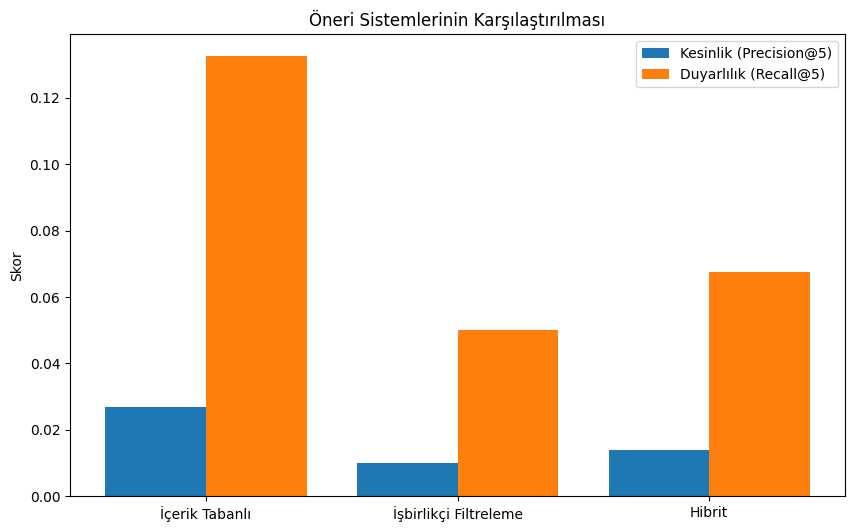

In [ ]:
import matplotlib.pyplot as plt

yontemler = ["İçerik Tabanlı", "İşbirlikçi Filtreleme", "Hibrit"]

precision_degerleri = [mean_p_c, mean_p_cf, mean_p_h]
recall_degerleri = [mean_r_c, mean_r_cf, mean_r_h]

x = range(len(yontemler))

plt.figure(figsize=(10,6))
plt.bar(x, precision_degerleri, width=0.4, label="Kesinlik (Precision@5)")
plt.bar([i + 0.4 for i in x], recall_degerleri, width=0.4, label="Duyarlılık (Recall@5)")

plt.xticks([i + 0.2 for i in x], yontemler)
plt.ylabel("Skor")
plt.title("Öneri Sistemlerinin Karşılaştırılması")
plt.legend()

plt.show()

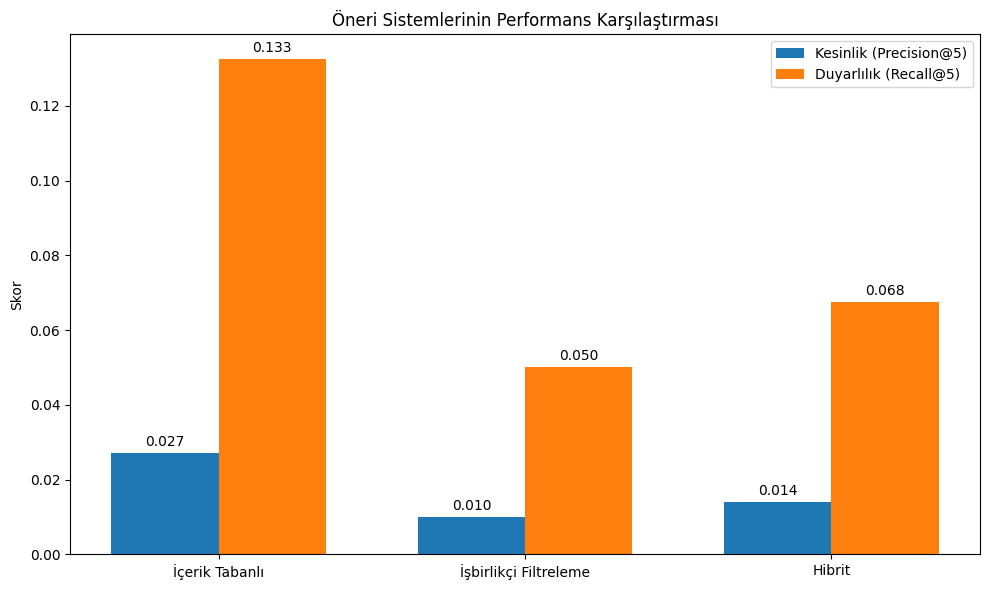

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_oneri_sistemleri_performans(mean_p_c, mean_r_c,
                                     mean_p_cf, mean_r_cf,
                                     mean_p_h, mean_r_h):

    yontemler = ["İçerik Tabanlı", "İşbirlikçi Filtreleme", "Hibrit"]
    precision_skorlari = [mean_p_c, mean_p_cf, mean_p_h]
    recall_skorlari = [mean_r_c, mean_r_cf, mean_r_h]

    x = np.arange(len(yontemler))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10,6))

    bars1 = ax.bar(x - width/2, precision_skorlari, width, label="Kesinlik (Precision@5)")
    bars2 = ax.bar(x + width/2, recall_skorlari, width, label="Duyarlılık (Recall@5)")

    ax.set_ylabel("Skor")
    ax.set_title("Öneri Sistemlerinin Performans Karşılaştırması")
    ax.set_xticks(x)
    ax.set_xticklabels(yontemler)
    ax.legend()

    # Değerleri bar üzerine yazdırma
    for bars in [bars1, bars2]:
        for bar in bars:
            yukseklik = bar.get_height()
            ax.annotate(f"{yukseklik:.3f}",
                        xy=(bar.get_x() + bar.get_width() / 2, yukseklik),
                        xytext=(0,3),
                        textcoords="offset points",
                        ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

plot_oneri_sistemleri_performans(
    mean_p_c, mean_r_c,
    mean_p_cf, mean_r_cf,
    mean_p_h, mean_r_h
)

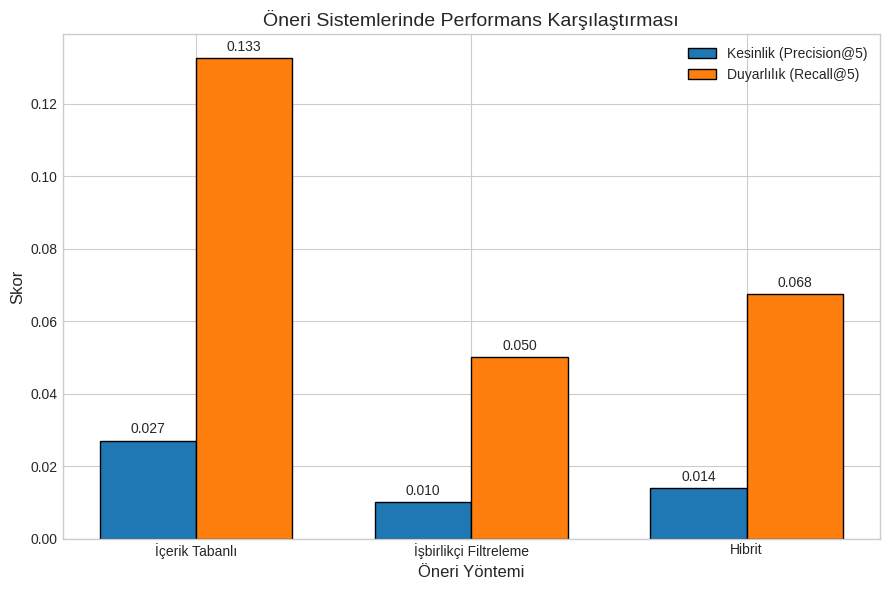

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_oneri_sistemleri_profesyonel(mean_p_c, mean_r_c,
                                      mean_p_cf, mean_r_cf,
                                      mean_p_h, mean_r_h):

    plt.style.use("seaborn-v0_8-whitegrid")

    yontemler = ["İçerik Tabanlı", "İşbirlikçi Filtreleme", "Hibrit"]
    precision = [mean_p_c, mean_p_cf, mean_p_h]
    recall = [mean_r_c, mean_r_cf, mean_r_h]

    x = np.arange(len(yontemler))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9,6))

    bars1 = ax.bar(x - width/2, precision, width,
                   label="Kesinlik (Precision@5)",
                   edgecolor="black")

    bars2 = ax.bar(x + width/2, recall, width,
                   label="Duyarlılık (Recall@5)",
                   edgecolor="black")

    ax.set_ylabel("Skor", fontsize=12)
    ax.set_xlabel("Öneri Yöntemi", fontsize=12)
    ax.set_title("Öneri Sistemlerinde Performans Karşılaştırması", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(yontemler)
    ax.legend()

    # Değerleri bar üstüne yazma
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2,
                    height + 0.002,
                    f"{height:.3f}",
                    ha="center", fontsize=10)

    plt.tight_layout()
    plt.show()


plot_oneri_sistemleri_profesyonel(
    mean_p_c, mean_r_c,
    mean_p_cf, mean_r_cf,
    mean_p_h, mean_r_h
)

## Jüri Geri Bildirimi Sonrası Ek Deneyler (Betül Hoca'nın notları doğrultusunda)

Aşağıdaki hücreler şunları ekler:
1. SVM ve Lojistik Regresyon için `class_weight='balanced'`, Naive Bayes için `sample_weight` (class_weight karşılığı) — hepsi zaten yukarıda tanımlı `run_tfidf_model` yardımcı fonksiyonunu kullanır.
2. MLP'yi ana karşılaştırmaya (SMOTE Yok + SMOTE Var) dahil eder — şimdiye kadar sadece ek analizde vardı.
3. **RNN + SMOTE** ve **gerçek CNN + SMOTE** (Embedding+Conv1D mimarisiyle, TF-IDF+Dense değil) — bunlar Claude'un sandbox ortamında TensorFlow kurulu olmadığı için çalıştırılamadı, bu yüzden burada, Colab'da senin çalıştırman gerekiyor.

NOT: 1 ve 2 numaralı gruptaki sonuçlar zaten Claude tarafından `filtered_data`'nın birebir aynısı (senin bilgisayarındaki Reviews 3.csv'den, aynı `random_state=42` ile) üzerinde çalıştırılıp teze işlendi; burada sadece tekrarlanabilirlik için kod olarak duruyorlar. Asıl ihtiyaç duyulan, hiç çalıştırılmamış olan 3 numaralı hücrelerdir.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight

def run_tfidf_model_classweight(df, model):
    X_train, X_test, y_train, y_test = split_data(df, 'cleaned_review', 'Sentiment')
    X_train_tfidf, X_test_tfidf, _ = vectorize_text(X_train, X_test)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return accuracy, report, cm

# SVM + class_weight
accuracy_svm_cw, report_svm_cw, cm_svm_cw = run_tfidf_model_classweight(
    filtered_data, LinearSVC(class_weight='balanced')
)
print("SVM - Class Weight")
print(accuracy_svm_cw); print(report_svm_cw); print(cm_svm_cw)

# Lojistik Regresyon + class_weight
accuracy_lr_cw, report_lr_cw, cm_lr_cw = run_tfidf_model_classweight(
    filtered_data, LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
)
print("Lojistik Regresyon - Class Weight")
print(accuracy_lr_cw); print(report_lr_cw); print(cm_lr_cw)

# Naive Bayes + sample_weight (class_weight'in NB karşılığı)
def naive_bayes_with_sample_weight(df):
    X_train, X_test, y_train, y_test = split_data(df, 'cleaned_review', 'Sentiment')
    X_train_tfidf, X_test_tfidf, _ = vectorize_text(X_train, X_test)
    weights = compute_sample_weight(class_weight='balanced', y=y_train)
    model = MultinomialNB()
    model.fit(X_train_tfidf, y_train, sample_weight=weights)
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return accuracy, report, cm

accuracy_nb_cw, report_nb_cw, cm_nb_cw = naive_bayes_with_sample_weight(filtered_data)
print("Naive Bayes - Sample Weight (class_weight karşılığı)")
print(accuracy_nb_cw); print(report_nb_cw); print(cm_nb_cw)

SVM - Class Weight
0.9146329653302344
              precision    recall  f1-score   support

           0       0.68      0.87      0.76      3235
           1       0.97      0.92      0.95     17417

    accuracy                           0.91     20652
   macro avg       0.83      0.89      0.85     20652
weighted avg       0.93      0.91      0.92     20652

[[ 2800   435]
 [ 1328 16089]]
Lojistik Regresyon - Class Weight
0.9085802827813286
              precision    recall  f1-score   support

           0       0.65      0.89      0.75      3235
           1       0.98      0.91      0.94     17417

    accuracy                           0.91     20652
   macro avg       0.82      0.90      0.85     20652
weighted avg       0.93      0.91      0.91     20652

[[ 2895   340]
 [ 1548 15869]]
Naive Bayes - Sample Weight (class_weight karşılığı)
0.8839337594421848
              precision    recall  f1-score   support

           0       0.59      0.89      0.70      3235
           1

MLP - SMOTE YOK
0.9353089289172961
              precision    recall  f1-score   support

           0       0.84      0.73      0.78      3235
           1       0.95      0.97      0.96     17417

    accuracy                           0.94     20652
   macro avg       0.89      0.85      0.87     20652
weighted avg       0.93      0.94      0.93     20652

[[ 2352   883]
 [  453 16964]]


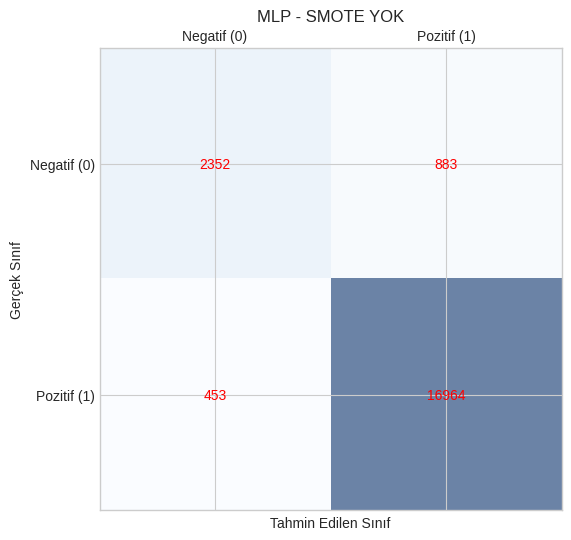

MLP - SMOTE VAR
0.9286751888436955
              precision    recall  f1-score   support

           0       0.77      0.77      0.77      3235
           1       0.96      0.96      0.96     17417

    accuracy                           0.93     20652
   macro avg       0.87      0.86      0.86     20652
weighted avg       0.93      0.93      0.93     20652

[[ 2492   743]
 [  730 16687]]


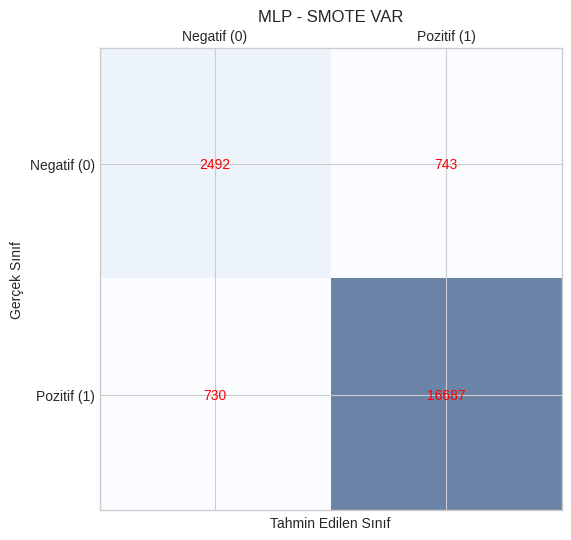

In [ ]:
from sklearn.neural_network import MLPClassifier

def run_mlp_experiment(df, model, use_smote=False):
    X_train, X_test, y_train, y_test = split_data(df, 'cleaned_review', 'Sentiment')
    X_train_tfidf, X_test_tfidf, _ = vectorize_text(X_train, X_test)
    if use_smote:
        X_train_tfidf, y_train = apply_smote(X_train_tfidf, y_train)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return accuracy, report, cm

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64,), max_iter=200, early_stopping=True, random_state=42
)
accuracy_ns, report_ns, cm_ns = run_mlp_experiment(filtered_data, mlp_model, use_smote=False)
print("MLP - SMOTE YOK")
print(accuracy_ns); print(report_ns); print(cm_ns)
plot_confusion_matrix(cm_ns, "MLP - SMOTE YOK")

mlp_model2 = MLPClassifier(
    hidden_layer_sizes=(64,), max_iter=200, early_stopping=True, random_state=42
)
accuracy_s, report_s, cm_s = run_mlp_experiment(filtered_data, mlp_model2, use_smote=True)
print("MLP - SMOTE VAR")
print(accuracy_s); print(report_s); print(cm_s)
plot_confusion_matrix(cm_s, "MLP - SMOTE VAR")

### ⬇️ Buradan itibaren ÇALIŞTIRILMASI GEREKEN hücreler (TensorFlow gerektirir, sadece Colab'da çalışır)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2178/2178 ━━━━━━━━━━━━━━━━━━━━ 425s 192ms/step - accuracy: 0.8326 - loss: 0.3742 - val_accuracy: 0.8922 - val_loss: 0.2641
Epoch 2/5
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 418s 192ms/step - accuracy: 0.9301 - loss: 0.1819 - val_accuracy: 0.9000 - val_loss: 0.2534
Epoch 3/5
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 417s 192ms/step - accuracy: 0.9655 - loss: 0.0962 - val_accuracy: 0.9054 - val_loss: 0.2725
Epoch 4/5
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 420s 193ms/step - accuracy: 0.9817 - loss: 0.0539 - val_accuracy: 0.8903 - val_loss: 0.3871
Epoch 5/5
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 418s 192ms/step - accuracy: 0.9877 - loss: 0.0358 - val_accuracy: 0.8911 - val_loss: 0.4462
646/646 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step
RNN - SMOTE Var
0.8910517141196979
              precision    recall  f1-score   support

           0       0.62      0.77      0.69      3235
           1       0.95      0.91      0.93     17417

    accuracy                           0.89     20652
   macro avg       0.79      0.84      0.81     2

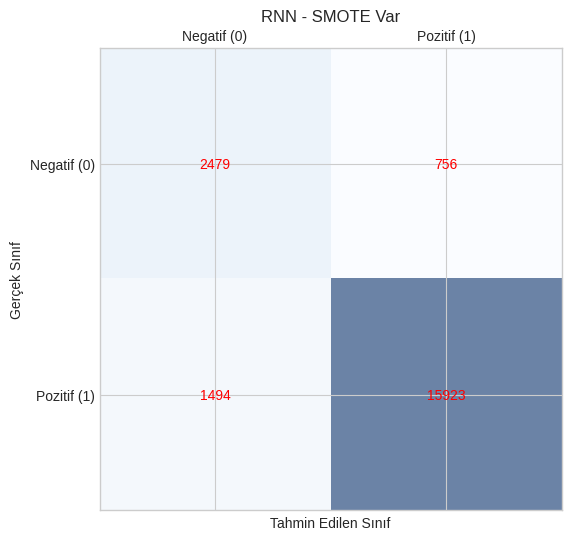

In [ ]:
def rnn_with_smote(df):
    """RNN (Bidirectional LSTM) - SMOTE ile dengelenmiş (padded token dizileri üzerinde).
    Not: SMOTE burada tam sayı token ID dizileri üzerinde enterpolasyon yapar; tezin
    class_weight tercihini gerekçelendiren metodolojik uyarı bu yüzdendir. Yine de
    jüri doğrudan bir karşılaştırma istediği için üretiliyor."""
    X_train, X_test, y_train, y_test = split_data(df, 'cleaned_review', 'Sentiment')
    max_length = 100
    X_train_padded, X_test_padded, tokenizer = preprocess_text_with_tokenizer(
        X_train, X_test, max_length
    )
    y_train = np.array(y_train)
    y_test = np.array(y_test)

    X_train_padded, y_train = apply_smote(X_train_padded, y_train)

    input_dim = len(tokenizer.word_index) + 1
    model = build_rnn_model(input_dim, max_length)

    model.fit(
        X_train_padded, y_train,
        epochs=5, batch_size=64,
        validation_data=(X_test_padded, y_test),
        verbose=1,
    )

    y_pred = (model.predict(X_test_padded) > 0.5).astype("int32").flatten()
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return accuracy, report, cm

accuracy_rnn_s, report_rnn_s, cm_rnn_s = rnn_with_smote(filtered_data)
print("RNN - SMOTE Var")
print(accuracy_rnn_s)
print(report_rnn_s)
print(cm_rnn_s)
plot_confusion_matrix(cm_rnn_s, "RNN - SMOTE Var")

Epoch 1/5
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 146s 66ms/step - accuracy: 0.8397 - loss: 0.3518 - val_accuracy: 0.8937 - val_loss: 0.2626
Epoch 2/5
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 154s 70ms/step - accuracy: 0.9476 - loss: 0.1381 - val_accuracy: 0.9009 - val_loss: 0.2633
Epoch 3/5
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 158s 72ms/step - accuracy: 0.9785 - loss: 0.0602 - val_accuracy: 0.9027 - val_loss: 0.3236
Epoch 4/5
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 158s 72ms/step - accuracy: 0.9872 - loss: 0.0358 - val_accuracy: 0.8910 - val_loss: 0.4355
Epoch 5/5
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 152s 70ms/step - accuracy: 0.9912 - loss: 0.0248 - val_accuracy: 0.8783 - val_loss: 0.5416
646/646 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
CNN - SMOTE Var (gerçek Conv1D mimarisi)
0.8783168700368003
              precision    recall  f1-score   support

           0       0.58      0.81      0.68      3235
           1       0.96      0.89      0.93     17417

    accuracy                           0.88     20652
   macro avg       0.

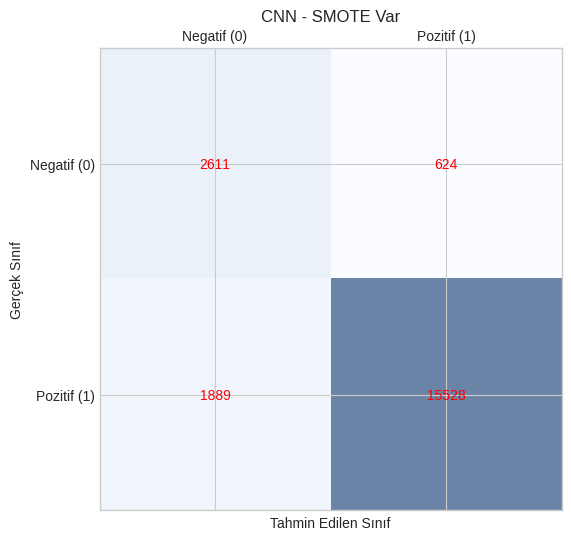

In [ ]:
def cnn_with_smote(df):
    """CNN (Embedding+Conv1D, mevcut build_cnn_model ile aynı mimari) - SMOTE ile dengelenmiş."""
    X_train, X_test, y_train, y_test = split_data(df, 'cleaned_review', 'Sentiment')
    max_length = 100
    X_train_pad, X_test_pad, tokenizer = preprocess_text_with_tokenizer(
        X_train, X_test, max_length
    )
    y_train = np.array(y_train)
    y_test = np.array(y_test)

    X_train_pad, y_train = apply_smote(X_train_pad, y_train)

    input_dim = len(tokenizer.word_index) + 1
    model = build_cnn_model(input_dim, max_length)

    model.fit(
        X_train_pad, y_train,
        epochs=5, batch_size=64,
        validation_data=(X_test_pad, y_test),
        verbose=1,
    )

    y_pred = (model.predict(X_test_pad) > 0.5).astype(int).flatten()
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return accuracy, report, cm

accuracy_cnn_s, report_cnn_s, cm_cnn_s = cnn_with_smote(filtered_data)
print("CNN - SMOTE Var (gerçek Conv1D mimarisi)")
print(accuracy_cnn_s)
print(report_cnn_s)
print(cm_cnn_s)
plot_confusion_matrix(cm_cnn_s, "CNN - SMOTE Var")

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1291/1291 ━━━━━━━━━━━━━━━━━━━━ 269s 203ms/step - accuracy: 0.9125 - loss: 0.2283 - val_accuracy: 0.9303 - val_loss: 0.1842
Epoch 2/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 258s 200ms/step - accuracy: 0.9557 - loss: 0.1225 - val_accuracy: 0.9331 - val_loss: 0.1892
Epoch 3/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 255s 198ms/step - accuracy: 0.9739 - loss: 0.0759 - val_accuracy: 0.9240 - val_loss: 0.2213
Epoch 4/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 259s 200ms/step - accuracy: 0.9827 - loss: 0.0513 - val_accuracy: 0.9256 - val_loss: 0.2584
Epoch 5/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 264s 205ms/step - accuracy: 0.9875 - loss: 0.0372 - val_accuracy: 0.9280 - val_loss: 0.3187
646/646 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step
RNN - Dengeleme Yok
0.927997288398218
              precision    recall  f1-score   support

           0       0.84      0.67      0.75      3235
           1       0.94      0.98      0.96     17417

    accuracy                           0.93     20652
   macro avg       0.89      0.82      0.85   

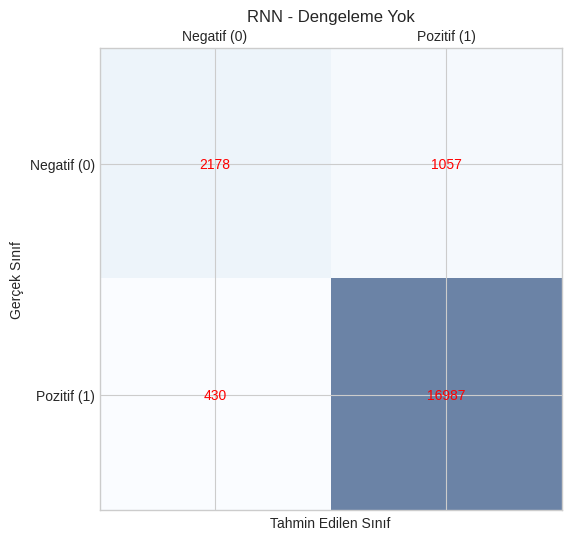

Epoch 1/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 90s 68ms/step - accuracy: 0.9099 - loss: 0.2292 - val_accuracy: 0.9319 - val_loss: 0.1768
Epoch 2/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 86s 67ms/step - accuracy: 0.9619 - loss: 0.1054 - val_accuracy: 0.9318 - val_loss: 0.1978
Epoch 3/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 87s 67ms/step - accuracy: 0.9952 - loss: 0.0141 - val_accuracy: 0.9278 - val_loss: 0.3914
Epoch 5/5
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 87s 67ms/step - accuracy: 0.9964 - loss: 0.0111 - val_accuracy: 0.9227 - val_loss: 0.4222
646/646 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
CNN - Dengeleme Yok (SMOTE yok)
0.9227193492155723
              precision    recall  f1-score   support

           0       0.75      0.76      0.76      3235
           1       0.96      0.95      0.95     17417

    accuracy                           0.92     20652
   macro avg       0.85      0.86      0.85     20652
weighted avg       0.92      0.92      0.92     20652

[[ 2468   767]
 [  829 16588]]


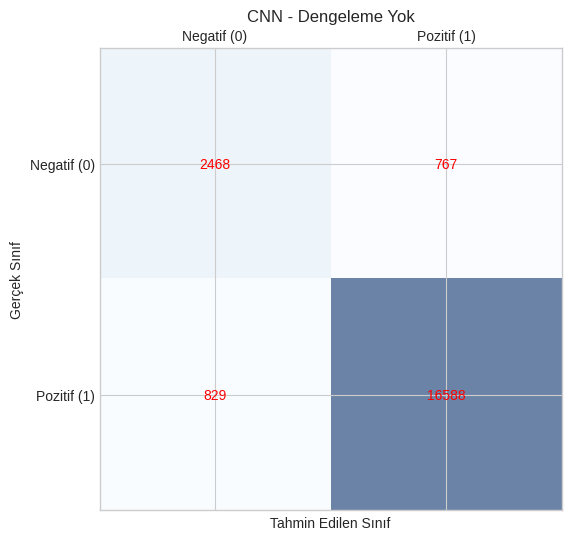

In [ ]:
# ============================================================================
# EKSİK DENEYLER: RNN ve CNN için "Dengeleme Yok" (baseline) koşuları
# ============================================================================
# Bu hücreleri Google Colab'da (GPU runtime ile), 30072026.ipynb notebook'unun
# sonuna ekleyip çalıştırman gerekiyor. Claude'un sandbox ortamında TensorFlow
# kurulu olmadığı için (pip/apt paket kurulumu bu ortamda engelli) bu iki
# deney çalıştırılamadı.
#
# Neden gerekli: Tablo 4.1a'da SVM, Naive Bayes, Lojistik Regresyon ve MLP
# için hem "Yok" (dengeleme uygulanmamış) hem "SMOTE Var" satırları var, ama
# RNN (BiLSTM) ve CNN için yalnızca "SMOTE Var" (cell 52, 53) ve "Class
# Weight" (cell 22, 29) satırları mevcut — tamamen dengesiz veri üzerinde
# eğitilmiş bir "Yok" baseline'ı hiç çalıştırılmamış. Bu iki hücre tam olarak
# o eksik koşuyu üretir. Çalıştırdıktan sonra çıkan accuracy / classification
# report / confusion matrix değerlerini bana ilet, Tablo 4.1a ve Tablo 4.3'e
# gerçek sonuçlarla ekleyeyim.
#
# Notebookta zaten tanımlı olan split_data, preprocess_text_with_tokenizer,
# build_rnn_model, build_cnn_model, plot_confusion_matrix fonksiyonlarını
# kullanır — bu hücrelerden önce o hücrelerin (11, 20, 21, 7, 28) çalıştırılmış
# olması gerekir (notebook'u baştan çalıştırırsan zaten hepsi sırayla çalışır).
# ============================================================================

import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


def rnn_baseline_no_balancing(df):
    """RNN (Bidirectional LSTM) - dengeleme UYGULANMADAN (ne class_weight ne SMOTE)."""
    X_train, X_test, y_train, y_test = split_data(df, 'cleaned_review', 'Sentiment')
    max_length = 100
    X_train_padded, X_test_padded, tokenizer = preprocess_text_with_tokenizer(
        X_train, X_test, max_length
    )
    y_train = np.array(y_train)
    y_test = np.array(y_test)

    input_dim = len(tokenizer.word_index) + 1
    model = build_rnn_model(input_dim, max_length)

    model.fit(
        X_train_padded, y_train,
        epochs=5, batch_size=64,
        validation_data=(X_test_padded, y_test),
        verbose=1,
    )

    y_pred = (model.predict(X_test_padded) > 0.5).astype("int32").flatten()
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return accuracy, report, cm


accuracy_rnn_ns, report_rnn_ns, cm_rnn_ns = rnn_baseline_no_balancing(filtered_data)
print("RNN - Dengeleme Yok")
print(accuracy_rnn_ns)
print(report_rnn_ns)
print(cm_rnn_ns)
plot_confusion_matrix(cm_rnn_ns, "RNN - Dengeleme Yok")


def cnn_baseline_no_balancing(df):
    """CNN (Embedding+Conv1D) - dengeleme UYGULANMADAN (ne class_weight ne SMOTE).
    Bu, kullanıcının istediği 'CNN (SMOTE yok)' deneyinin tam karşılığıdır."""
    X_train, X_test, y_train, y_test = split_data(df, 'cleaned_review', 'Sentiment')
    max_length = 100
    X_train_pad, X_test_pad, tokenizer = preprocess_text_with_tokenizer(
        X_train, X_test, max_length
    )
    y_train = np.array(y_train)
    y_test = np.array(y_test)

    input_dim = len(tokenizer.word_index) + 1
    model = build_cnn_model(input_dim, max_length)

    model.fit(
        X_train_pad, y_train,
        epochs=5, batch_size=64,
        validation_data=(X_test_pad, y_test),
        verbose=1,
    )

    y_pred = (model.predict(X_test_pad) > 0.5).astype(int).flatten()
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return accuracy, report, cm


accuracy_cnn_ns, report_cnn_ns, cm_cnn_ns = cnn_baseline_no_balancing(filtered_data)
print("CNN - Dengeleme Yok (SMOTE yok)")
print(accuracy_cnn_ns)
print(report_cnn_ns)
print(cm_cnn_ns)
plot_confusion_matrix(cm_cnn_ns, "CNN - Dengeleme Yok")